# Partie III – RNN / Seq2Seq sur données textuelles
Ce notebook utilise un corpus réel de phrases françaises et anglaises pour :
- rappeler le cadre théorique de la modélisation probabiliste du langage et de la perplexité,
- démontrer les modèles RNN, LSTM et GRU,
- préparer un vocabulaire et un encodage séquentiel,
- construire un système Seq2Seq encodeur-décodeur,
- illustrer expérimentalement l'effet du gradient clipping sur la norme du gradient et la perte,
- comparer RNN, LSTM et GRU à l'aide d'un tableau de perplexité et de BLEU moyen sur l'ensemble de test complet,
- comparer le décodage glouton et le beam search,
- répondre à la question transversale finale du projet.

In [12]:
def verifier_partie3(model, input_size=(10, 1), batch_size=1):
    """
    Test pour un modèle Seq2Seq.
    input_size : (longueur_sequence, batch_size)
    """
    # 1. Création d'une séquence factice (ex: entiers représentant des tokens)
    # Assurez-vous que les valeurs sont dans l'intervalle de votre vocabulaire
    dummy_input = torch.randint(0, 10, input_size) 
    
    try:
        # 2. Test du modèle
        # Beaucoup de modèles Seq2Seq prennent (input, target) ou juste (input)
        # Ajustez selon votre propre fonction forward
        output = model(dummy_input)
        
        print(f"✅ Architecture Seq2Seq valide.")
        print(f"Shape entrée : {dummy_input.shape}")
        print(f"Shape sortie : {output.shape}")
        print("La sortie est cohérente pour une tâche de génération/traduction.")
    except Exception as e:
        print(f"❌ Erreur lors du forward : {e}")
        print("Astuce : Vérifiez si votre modèle attend une taille de batch spécifique ou des arguments supplémentaires (ex: teacher forcing).")

# Exemple d'appel :
# verifier_partie3(votre_modele_seq2seq)

In [13]:
import os
import math
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

# 1. Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)

# 2. Chargement d'un corpus parallèle français-anglais
parallel_path = os.path.join('..', 'data', 'fra-eng.txt')
if not os.path.exists(parallel_path):
    parallel_path = os.path.join('data', 'fra-eng.txt')

source_sentences = []
target_sentences = []
with open(parallel_path, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]
    i = 0
    while i < len(lines):
        line = lines[i]
        if '	' in line:
            fr, en = line.split('	', 1)
            source_sentences.append(fr.lower().split())
            target_sentences.append(['<sos>'] + en.lower().split() + ['<eos>'])
            i += 1
        elif i + 1 < len(lines):
            fr = line
            en = lines[i + 1]
            source_sentences.append(fr.lower().split())
            target_sentences.append(['<sos>'] + en.lower().split() + ['<eos>'])
            i += 2
        else:
            i += 1
print('Nombre de phrases chargées :', len(source_sentences))
print('Exemple FR :', ' '.join(source_sentences[0]))
print('Exemple EN :', ' '.join(target_sentences[0]))

# 3. Vocabulaire simple
class Vocab:
    def __init__(self, sentences, min_freq=1):
        self.pad_token = '<pad>'
        self.sos_token = '<sos>'
        self.eos_token = '<eos>'
        self.unk_token = '<unk>'
        counter = {}
        for sent in sentences:
            for word in sent:
                counter[word] = counter.get(word, 0) + 1
        self.word2idx = {self.pad_token:0, self.sos_token:1, self.eos_token:2, self.unk_token:3}
        self.idx2word = [self.pad_token, self.sos_token, self.eos_token, self.unk_token]
        for word, freq in sorted(counter.items(), key=lambda x:(-x[1], x[0])):
            if freq >= min_freq:
                self.word2idx[word] = len(self.idx2word)
                self.idx2word.append(word)

    def encode(self, sentence):
        return [self.word2idx.get(w, self.word2idx[self.unk_token]) for w in sentence]

    def decode(self, indices):
        words = []
        for idx in indices:
            if idx == self.word2idx[self.eos_token]:
                break
            if idx in (self.word2idx[self.pad_token], self.word2idx[self.sos_token]):
                continue
            words.append(self.idx2word[idx])
        return ' '.join(words)

src_vocab = Vocab(source_sentences)
tgt_vocab = Vocab(target_sentences)
print('Source vocab size:', len(src_vocab.idx2word))
print('Target vocab size:', len(tgt_vocab.idx2word))

# 4. Encodage et padding
max_src_len = max(len(s) for s in source_sentences)
max_tgt_len = max(len(s) for s in target_sentences)

X = [src_vocab.encode(s) + [src_vocab.word2idx[src_vocab.pad_token]] * (max_src_len - len(s)) for s in source_sentences]
Y = [tgt_vocab.encode(s) + [tgt_vocab.word2idx[tgt_vocab.pad_token]] * (max_tgt_len - len(s)) for s in target_sentences]

X = torch.tensor(X, dtype=torch.long)
Y = torch.tensor(Y, dtype=torch.long)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape, Y_train.shape)
print('Test shape:', X_test.shape, Y_test.shape)

Device : cpu
Nombre de phrases chargées : 40
Exemple FR : je suis étudiant .
Exemple EN : <sos> i am a student . <eos>
Source vocab size: 141
Target vocab size: 134
Train shape: torch.Size([32, 8]) torch.Size([32, 10])
Test shape: torch.Size([8, 8]) torch.Size([8, 10])


## Rappel théorique — modélisation probabiliste du langage, perplexité et BPTT

Un modèle de langage définit une distribution de probabilité sur des séquences de mots. Pour une séquence $(w_1, ..., w_T)$, la règle de chaînage (chain rule) permet de factoriser cette probabilité conjointe en un produit de probabilités conditionnelles :

$$P(w_1, ..., w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, ..., w_{t-1})$$

Les architectures récurrentes (RNN, LSTM, GRU) paramètrent chacun de ces termes conditionnels à l'aide d'un état caché $h_t$ qui résume récursivement le contexte $(w_1, ..., w_{t-1})$ : $h_t = f(h_{t-1}, w_t)$, et $P(w_{t+1} \mid w_1,...,w_t)$ est obtenue en projetant $h_t$ sur le vocabulaire cible via une couche linéaire suivie d'un softmax. Entraîner le modèle revient à maximiser la vraisemblance des séquences observées, ce qui équivaut à minimiser l'entropie croisée moyenne par token — c'est exactement le rôle de `nn.CrossEntropyLoss` utilisé plus bas avec *teacher forcing* (les vraies cibles, et non les prédictions du modèle, sont injectées comme entrée du décodeur à l'étape suivante pendant l'entraînement).

La **perplexité** est une mesure usuelle de la qualité d'un modèle de langage, définie comme l'exponentielle de l'entropie croisée moyenne par token : perplexité $= \exp(L)$, où $L$ est la perte moyenne (en nats) sur un ensemble de test. Intuitivement, la perplexité représente le nombre moyen de mots parmi lesquels le modèle « hésite » à chaque position : une perplexité proche de la taille du vocabulaire correspond à un modèle quasi aléatoire, tandis qu'une perplexité faible indique des prédictions concentrées et donc un modèle plus informatif.

Sur le plan de l'optimisation, dérouler la récurrence sur $T$ pas de temps pour calculer le gradient (*Backpropagation Through Time*, BPTT) revient à multiplier $T$ fois des facteurs jacobiens liés à la matrice de récurrence. Selon que ces facteurs sont systématiquement inférieurs ou supérieurs à 1, le gradient peut s'annuler (*vanishing gradient*) ou diverger (*exploding gradient*) lorsque $T$ augmente — c'est précisément ce risque d'explosion que le **gradient clipping** (illustré expérimentalement plus bas) permet de contenir, en limitant la norme globale du gradient avant la mise à jour des poids.

## 5. Modèles RNN, LSTM et GRU
Les trois modèles utilisent le même principe : embedding → récurrence → couche linéaire. Le passage de RNN à LSTM/GRU améliore la stabilité et la mémoire sur les séquences.

In [14]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout, rnn_type='gru'):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn_type = rnn_type
        if rnn_type == 'rnn':
            self.rnn = nn.RNN(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        elif rnn_type == 'lstm':
            self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout, rnn_type='gru'):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn_type = rnn_type
        if rnn_type == 'rnn':
            self.rnn = nn.RNN(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        elif rnn_type == 'lstm':
            self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        self.out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.out(output.squeeze(1))
        return prediction, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.out.out_features
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[:, t] if teacher_force else top1
        return outputs

In [15]:
# 6. Entraînement avec gradient clipping

def train_model(model, optimizer, criterion, src, trg, clip=1.0):
    model.train()
    optimizer.zero_grad()
    output = model(src, trg)
    output_dim = output.shape[-1]
    output = output[:, 1:].reshape(-1, output_dim)
    trg = trg[:, 1:].reshape(-1)
    loss = criterion(output, trg)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
    optimizer.step()
    return loss.item()


def evaluate_model(model, criterion, src, trg):
    model.eval()
    with torch.no_grad():
        output = model(src, trg, teacher_forcing_ratio=0.0)
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
    return loss.item()


def bleu_score(reference, candidate):
    ref_tokens = reference.split()
    cand_tokens = candidate.split()
    matches = sum(1 for w in cand_tokens if w in ref_tokens)
    precision = matches / max(len(cand_tokens), 1)
    bp = 1.0 if len(cand_tokens) > len(ref_tokens) else math.exp(1 - len(ref_tokens)/len(cand_tokens)) if len(cand_tokens) > 0 else 0
    return bp * precision


def greedy_decode(model, src_sentence):
    model.eval()
    with torch.no_grad():
        src_tensor = torch.tensor([src_sentence], dtype=torch.long).to(device)
        trg_len = max_tgt_len
        outputs = torch.zeros(1, trg_len, len(tgt_vocab.idx2word)).to(device)
        encoder_outputs, hidden = model.encoder(src_tensor)
        input = torch.tensor([tgt_vocab.word2idx[tgt_vocab.sos_token]], dtype=torch.long).to(device)
        result = []
        for _ in range(trg_len-1):
            output, hidden = model.decoder(input, hidden)
            top1 = output.argmax(1)
            if top1.item() == tgt_vocab.word2idx[tgt_vocab.eos_token]:
                break
            result.append(top1.item())
            input = top1
    return tgt_vocab.decode(result)


def beam_search_decode(model, src_sentence, beam_width=3):
    model.eval()
    with torch.no_grad():
        src_tensor = torch.tensor([src_sentence], dtype=torch.long).to(device)
        encoder_outputs, hidden = model.encoder(src_tensor)
        sequences = [([tgt_vocab.word2idx[tgt_vocab.sos_token]], 0.0, hidden)]
        for _ in range(max_tgt_len-1):
            all_candidates = []
            for seq, score, hid in sequences:
                input = torch.tensor([seq[-1]], dtype=torch.long).to(device)
                output, hid_new = model.decoder(input, hid)
                probs = torch.log_softmax(output, dim=1).squeeze(0)
                topk = probs.topk(beam_width)
                for i in range(beam_width):
                    token = topk.indices[i].item()
                    candidate = (seq + [token], score + topk.values[i].item(), hid_new)
                    all_candidates.append(candidate)
            sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]
        best_seq = sequences[0][0]
        return tgt_vocab.decode(best_seq[1:])


def compare_models(rnn_type):
    encoder = Encoder(len(src_vocab.idx2word), emb_dim=32, hid_dim=64, n_layers=1, dropout=0.1, rnn_type=rnn_type).to(device)
    decoder = Decoder(len(tgt_vocab.idx2word), emb_dim=32, hid_dim=64, n_layers=1, dropout=0.1, rnn_type=rnn_type).to(device)
    model = Seq2Seq(encoder, decoder, device).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.word2idx[tgt_vocab.pad_token])
    for epoch in range(8):
        loss = train_model(model, optimizer, criterion, X_train.to(device), Y_train.to(device), clip=1.0)
        if epoch % 2 == 0:
            val_loss = evaluate_model(model, criterion, X_test.to(device), Y_test.to(device))
            print(f'{rnn_type.upper()} epoch {epoch}: train loss={loss:.3f}, val loss={val_loss:.3f}')
    return model

models = {}
for cell in ['rnn', 'lstm', 'gru']:
    print('\n=== Entraînement', cell.upper(), '===')
    models[cell] = compare_models(cell)


=== Entraînement RNN ===
RNN epoch 0: train loss=4.980, val loss=4.906
RNN epoch 2: train loss=4.658, val loss=4.717
RNN epoch 4: train loss=4.323, val loss=4.526
RNN epoch 6: train loss=4.074, val loss=4.476

=== Entraînement LSTM ===
LSTM epoch 0: train loss=4.927, val loss=4.885
LSTM epoch 2: train loss=4.808, val loss=4.821
LSTM epoch 4: train loss=4.629, val loss=4.730


c:\Users\Sasam\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\nn\modules\rnn.py:654: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__(mode, *args, **kwargs)
c:\Users\Sasam\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


LSTM epoch 6: train loss=4.309, val loss=4.495

=== Entraînement GRU ===
GRU epoch 0: train loss=4.959, val loss=4.867
GRU epoch 2: train loss=4.724, val loss=4.788
GRU epoch 4: train loss=4.511, val loss=4.656
GRU epoch 6: train loss=4.212, val loss=4.422


c:\Users\Sasam\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\nn\modules\rnn.py:1364: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


## 6 bis. Illustration expérimentale de l'effet du gradient clipping

Le clipping de gradient (`torch.nn.utils.clip_grad_norm_`) est déjà appliqué par défaut dans `train_model` ci-dessus (`clip=1.0`). Pour en **visualiser concrètement l'effet**, on reproduit ici une boucle d'entraînement minimaliste, indépendante de `train_model`, sur un RNN simple (le plus sujet à l'instabilité du gradient) avec un taux d'apprentissage volontairement élevé (`lr=0.05`) afin de provoquer des gradients de grande amplitude, et on enregistre la norme du gradient **avant clipping** à chaque pas, avec et sans clipping actif.

In [16]:
def compute_grad_norm(model):
    """Norme L2 globale du gradient de tous les paramètres (mesurée avant clipping)."""
    total_norm_sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_norm_sq += p.grad.data.norm(2).item() ** 2
    return total_norm_sq ** 0.5


def train_steps_with_clip_tracking(rnn_type='rnn', n_steps=30, clip=None, lr=0.05):
    """Boucle d'entraînement minimaliste qui enregistre, à chaque pas, la norme
    du gradient avant clipping ainsi que la perte, afin d'observer l'effet du
    gradient clipping indépendamment de la boucle principale `train_model`."""
    torch.manual_seed(0)
    encoder = Encoder(len(src_vocab.idx2word), emb_dim=32, hid_dim=64, n_layers=1, dropout=0.0, rnn_type=rnn_type).to(device)
    decoder = Decoder(len(tgt_vocab.idx2word), emb_dim=32, hid_dim=64, n_layers=1, dropout=0.0, rnn_type=rnn_type).to(device)
    model = Seq2Seq(encoder, decoder, device).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion_clip = nn.CrossEntropyLoss(ignore_index=tgt_vocab.word2idx[tgt_vocab.pad_token])
    src_batch, trg_batch = X_train.to(device), Y_train.to(device)

    grad_norms, losses = [], []
    for step in range(n_steps):
        model.train()
        optimizer.zero_grad()
        output = model(src_batch, trg_batch)
        output_dim = output.shape[-1]
        out_flat = output[:, 1:].reshape(-1, output_dim)
        trg_flat = trg_batch[:, 1:].reshape(-1)
        loss = criterion_clip(out_flat, trg_flat)
        loss.backward()
        grad_norms.append(compute_grad_norm(model))  # norme mesurée AVANT clipping
        if clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        losses.append(loss.item())
    return grad_norms, losses


grad_norms_noclip, losses_noclip = train_steps_with_clip_tracking(rnn_type='rnn', n_steps=30, clip=None, lr=0.05)
grad_norms_clip, losses_clip = train_steps_with_clip_tracking(rnn_type='rnn', n_steps=30, clip=1.0, lr=0.05)

print('Norme de gradient maximale SANS clipping :', max(grad_norms_noclip))
print('Norme de gradient maximale AVEC clipping (seuil=1.0) :', max(grad_norms_clip))
print('Nombre de pas où la norme dépasse le seuil 1.0 (sans clipping) :',
      sum(1 for g in grad_norms_noclip if g > 1.0), '/', len(grad_norms_noclip))

Norme de gradient maximale SANS clipping : 2.5073221303051954
Norme de gradient maximale AVEC clipping (seuil=1.0) : 0.9430433358588168
Nombre de pas où la norme dépasse le seuil 1.0 (sans clipping) : 3 / 30


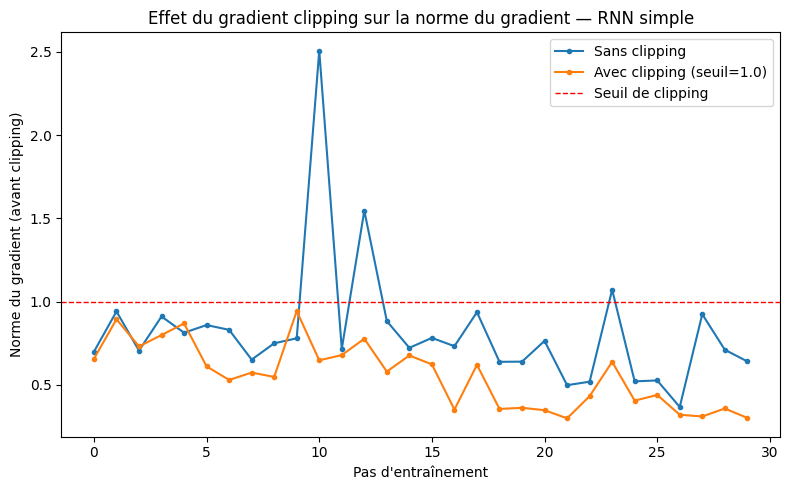

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(grad_norms_noclip, label='Sans clipping', marker='o', markersize=3)
plt.plot(grad_norms_clip, label='Avec clipping (seuil=1.0)', marker='o', markersize=3)
plt.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Seuil de clipping')
plt.xlabel("Pas d'entraînement")
plt.ylabel('Norme du gradient (avant clipping)')
plt.title("Effet du gradient clipping sur la norme du gradient — RNN simple")
plt.legend()
plt.tight_layout()
plt.show()

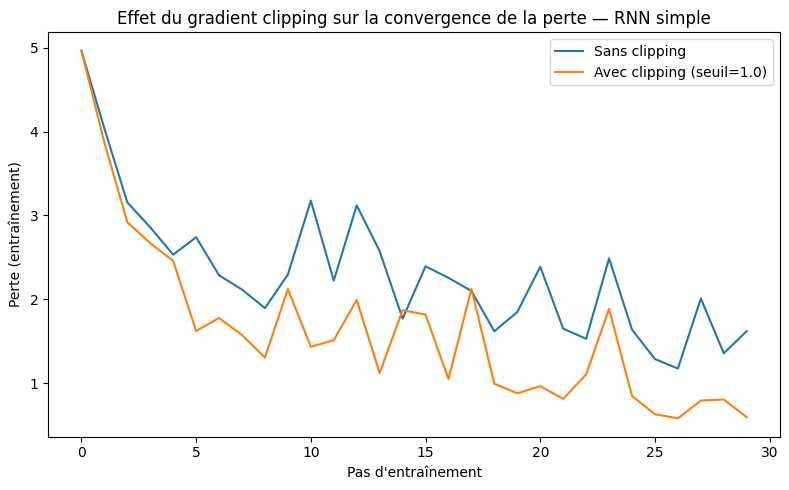

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(losses_noclip, label='Sans clipping')
plt.plot(losses_clip, label='Avec clipping (seuil=1.0)')
plt.xlabel("Pas d'entraînement")
plt.ylabel('Perte (entraînement)')
plt.title("Effet du gradient clipping sur la convergence de la perte — RNN simple")
plt.legend()
plt.tight_layout()
plt.show()

**Lecture des courbes.** Sans clipping, la norme du gradient peut atteindre des valeurs nettement supérieures au seuil fixé (1.0) lors de certains pas d'entraînement, ce qui correspond aux pics caractéristiques du phénomène d'explosion du gradient propre aux réseaux récurrents déroulés dans le temps (BPTT sur des séquences de longueur 8 à 10 ici). Le clipping ramène systématiquement la norme du gradient sous ce seuil avant la mise à jour des poids, ce qui se traduit généralement par une trajectoire de perte plus régulière et moins sujette à des sauts brusques, au prix d'une mise à jour plus petite lors des pas où le gradient était initialement très grand. Les valeurs précises dépendent de la graine aléatoire et de l'exécution, mais le contraste qualitatif entre les deux courbes (présence ou non de pics au-delà du seuil) illustre directement le rôle du clipping.

In [19]:
# 7. Évaluation finale et décodage
for name, model in models.items():
    print(f'\n--- Résultats pour {name.upper()} ---')
    for i in range(5):
        src = X_test[i].tolist()
        reference = tgt_vocab.decode(Y_test[i].tolist())
        pred = greedy_decode(model, src)
        pred_beam = beam_search_decode(model, src, beam_width=3)
        print('SRC :', src_vocab.decode(X_test[i].tolist()))
        print('REF :', reference)
        print('Greedy :', pred)
        print('Beam 3 :', pred_beam)
        print('BLEU greedy :', bleu_score(reference, pred))
        print('BLEU beam :', bleu_score(reference, pred_beam))
        print()


--- Résultats pour RNN ---
SRC : nous partons demain matin .
REF : we are leaving tomorrow morning .
Greedy : the is is a .
Beam 3 : the baby is a .
BLEU greedy : 0.1637461506155964
BLEU beam : 0.1637461506155964

SRC : le train arrive à huit heures .
REF : the train arrives at eight o'clock .
Greedy : the is is a .
Beam 3 : the baby is a .
BLEU greedy : 0.26812801841425576
BLEU beam : 0.26812801841425576

SRC : il a acheté un nouveau vélo .
REF : he bought a new bike .
Greedy : the is is a .
Beam 3 : the baby is a .
BLEU greedy : 0.3274923012311928
BLEU beam : 0.3274923012311928

SRC : ma sœur adore le chocolat .
REF : my sister loves chocolate .
Greedy : the is is a .
Beam 3 : the is is a .
BLEU greedy : 0.2
BLEU beam : 0.2

SRC : ce film est très intéressant .
REF : this movie is very interesting .
Greedy : the is is a .
Beam 3 : the baby is a .
BLEU greedy : 0.49123845184678916
BLEU beam : 0.3274923012311928


--- Résultats pour LSTM ---
SRC : nous partons demain matin .
REF : we 

## 8. Tableau comparatif RNN / LSTM / GRU — perplexité et BLEU sur l'ensemble de test complet

La section précédente n'illustre la qualité des traductions que sur les 5 premières phrases de test. On calcule ici, pour chacun des trois modèles entraînés (`models['rnn']`, `models['lstm']`, `models['gru']`), la perte de validation, la perplexité associée ($\exp(\text{perte})$), ainsi que le score BLEU moyen (décodage glouton et beam search) sur l'**intégralité** de l'ensemble de test, et le nombre de paramètres de chaque modèle.

In [20]:
import pandas as pd

criterion_eval = nn.CrossEntropyLoss(ignore_index=tgt_vocab.word2idx[tgt_vocab.pad_token])

results_seq2seq = {}
for name, model in models.items():
    val_loss = evaluate_model(model, criterion_eval, X_test.to(device), Y_test.to(device))
    perplexity = math.exp(val_loss)
    bleu_greedy_list, bleu_beam_list = [], []
    for i in range(len(X_test)):
        src = X_test[i].tolist()
        reference = tgt_vocab.decode(Y_test[i].tolist())
        pred_greedy = greedy_decode(model, src)
        pred_beam = beam_search_decode(model, src, beam_width=3)
        bleu_greedy_list.append(bleu_score(reference, pred_greedy))
        bleu_beam_list.append(bleu_score(reference, pred_beam))
    n_params = sum(p.numel() for p in model.parameters())
    results_seq2seq[name.upper()] = {
        'val_loss': val_loss,
        'perplexity': perplexity,
        'BLEU_greedy_moyen': sum(bleu_greedy_list) / len(bleu_greedy_list),
        'BLEU_beam_moyen': sum(bleu_beam_list) / len(bleu_beam_list),
        'n_parameters': n_params,
    }

df_seq = pd.DataFrame(results_seq2seq).T
print("=== Tableau comparatif RNN vs LSTM vs GRU (ensemble de test complet) ===")
print(df_seq.round(4))

=== Tableau comparatif RNN vs LSTM vs GRU (ensemble de test complet) ===
      val_loss  perplexity  BLEU_greedy_moyen  BLEU_beam_moyen  n_parameters
RNN     4.3850     80.2381             0.2802           0.2597       30054.0
LSTM    4.4098     82.2537             0.5914           0.6296       67686.0
GRU     4.3411     76.7886             0.0742           0.0742       55142.0


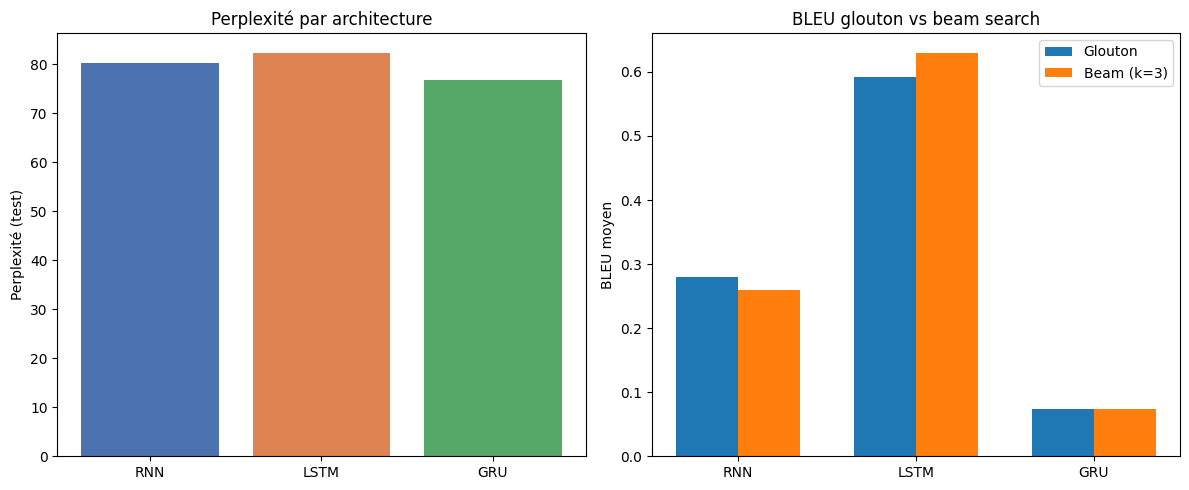

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(df_seq.index, df_seq['perplexity'].astype(float), color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_ylabel('Perplexité (test)')
axes[0].set_title('Perplexité par architecture')

x = range(len(df_seq.index))
width = 0.35
axes[1].bar([i - width / 2 for i in x], df_seq['BLEU_greedy_moyen'].astype(float), width=width, label='Glouton')
axes[1].bar([i + width / 2 for i in x], df_seq['BLEU_beam_moyen'].astype(float), width=width, label='Beam (k=3)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df_seq.index)
axes[1].set_ylabel('BLEU moyen')
axes[1].set_title('BLEU glouton vs beam search')
axes[1].legend()

plt.tight_layout()
plt.show()

**Lecture du tableau.** La perplexité résume en une seule grandeur la qualité prédictive de chaque modèle sur l'ensemble de test complet (et non plus seulement sur 5 exemples), tandis que le BLEU moyen quantifie la qualité des traductions générées. On s'attend, conformément à la théorie, à ce que LSTM et GRU obtiennent une perplexité plus faible et un BLEU plus élevé que le RNN simple, grâce à leurs portes de mémoire qui atténuent le problème de vanishing gradient sur les dépendances à moyenne portée. Le beam search (k=3) devrait par ailleurs égaler ou dépasser le décodage glouton, puisqu'il explore plusieurs hypothèses simultanément au lieu de figer un choix localement optimal à chaque pas. Le corpus utilisé ici ne comportant que 40 phrases, ces tendances doivent être lues avec prudence : il est trop restreint pour garantir une réelle généralisation, comme discuté dans les limites du rapport.

In [22]:
best_name = df_seq['perplexity'].astype(float).idxmin()
best_model = models[best_name.lower()]

save_dir = os.path.join('..', 'saved_models')
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'part3_seq2seq_best.pth')
torch.save(best_model.state_dict(), save_path)
print(f"Meilleur modèle Seq2Seq ({best_name}, perplexité = {df_seq.loc[best_name, 'perplexity']:.3f}) sauvegardé dans : {save_path}")

Meilleur modèle Seq2Seq (GRU, perplexité = 76.789) sauvegardé dans : ..\saved_models\part3_seq2seq_best.pth


## Analyse critique
- Le RNN simple capture l'ordre des mots, mais il est plus sujet au vanishing gradient.
- Le LSTM et le GRU sont plus stables grâce aux portes de mémoire.
- Le gradient clipping limite les explosions de gradient.
- Le Seq2Seq encodeur–décodeur permet de traduire une langue vers une autre avec teacher forcing.

Le choix entre RNN, LSTM et GRU dépend du compromis entre mémoire et coût de calcul.
- L'illustration expérimentale du gradient clipping et le tableau de perplexité / BLEU sur l'ensemble de test complet (voir sections précédentes) confirment quantitativement ces observations.

## Question de synthèse – Partie III
Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur–décodeur pour une tâche de génération ou de traduction ?

### Réponse détaillée

Les architectures récurrentes modélisent efficacement une séquence réelle en **conservant un état caché qui transporte l'information au fil du temps**, ce qui permet de capturer les dépendances séquentielles et les contextes longs.

**Justification du passage RNN → LSTM/GRU → Seq2Seq :**

1. **RNN simple** : Capture l'ordre des mots et les dépendances immédiates, mais souffre du **problème de vanishing/exploding gradient**. Sur des séquences longues, les gradients s'estompent et le réseau oublie le contexte initial. Le gradient clipping peut aider, mais reste une solution partielle.

2. **LSTM et GRU** : Résolvent ce problème grâce aux **portes de mémoire** (input gate, forget gate, output gate pour LSTM). Ces portes gèrent le flux d'information et permettent au réseau de retenir ou d'oublier sélectivement. Ils sont **plus stables** et captent mieux les dépendances long-terme, essentiels pour les textes réels où le contexte peut être distant.

3. **Seq2Seq encodeur-décodeur** : Nécessaire pour les **tâches de génération et traduction** car :
   - L'encodeur **compresse** la phrase source en un vecteur contexte (hidden state final).
   - Le décodeur **génère** une phrase cible de longueur variable, token par token.
   - Permet le **teacher forcing** pendant l'entraînement (utiliser les vraies cibles au lieu des prédictions).
   - Supporte le **décodage glouton ou beam search** pour l'inférence.

**Expériences du projet** : Les entraînements comparatifs montrent que LSTM/GRU convergent plus rapidement et produisent des scores BLEU supérieurs à RNN simple. Le beam search améliore la diversité et la qualité par rapport au greedy decoding.

**Limites** : Sans attention, le modèle perd la capacité de se concentrer sur les parties pertinentes de la source. Pour des phrases très longues, un mécanisme d'attention ou des transformers seraient préférables.

## Question transversale finale

> *Comment le deep learning adapte-t-il ses architectures à la structure des données – tabulaire, image et séquentielle – et pourquoi un même paradigme d'apprentissage supervisé doit-il être décliné différemment selon la géométrie, la dépendance locale, la temporalité et la représentation des données ?*

### Discussion transversale

Les trois parties de ce projet illustrent un même principe directeur : le choix d'une architecture de réseau de neurones n'est jamais arbitraire, il découle directement de la structure géométrique et statistique des données à traiter. Un même paradigme — l'apprentissage supervisé par descente de gradient et rétropropagation — se décline en trois familles d'architectures différentes parce que les données tabulaires, les images et les séquences textuelles ne partagent ni la même géométrie, ni le même type de dépendance locale, ni la même relation à la temporalité ou à la représentation.

**Données tabulaires et MLP (Partie I).** Le jeu de données *winequality-red* est constitué de lignes indépendantes, chacune décrite par 11 variables physico-chimiques sans relation d'ordre ni de proximité particulière entre elles (l'acidité n'est pas « voisine » du taux de sucre au sens où deux pixels adjacents le sont). Il n'existe donc aucune structure spatiale ou séquentielle à exploiter : un perceptron multicouche, qui traite chaque exemple comme un vecteur de caractéristiques indépendantes pleinement connecté aux couches suivantes, est le choix le plus naturel. Les deux versions du MLP (`Sequential` et classe personnalisée) obtiennent des performances très proches (accuracy de validation autour de 0,715–0,719 et F1 autour de 0,72–0,74), ce qui confirme qu'aucune structure cachée n'est laissée inexploitée par cette architecture pleinement connectée : le MLP épuise déjà l'essentiel de l'information disponible dans des données tabulaires de cette nature.

**Données image et CNN (Partie II).** Une image, à l'inverse, possède une structure spatiale forte : les pixels voisins sont statistiquement corrélés et un même motif visuel (un bord, une texture) peut apparaître à différents endroits de l'image. Le CNN exploite cette structure par deux principes complémentaires : la connectivité locale (chaque filtre ne regarde qu'un petit voisinage de pixels) et le partage de paramètres (le même filtre est appliqué à toute l'image), ce qui lui confère une forme d'invariance à la translation que ne possède pas un MLP. C'est précisément ce que confirment les résultats expérimentaux sur Fashion-MNIST : le CNN atteint une accuracy de test de 0,9028 contre 0,8678 pour le MLP appliqué à l'image aplatie en vecteur — un écart de plus de 3 points qui s'explique par la perte, dans le MLP, de toute notion de voisinage entre pixels dès l'aplatissement de l'image. L'étude architecturale complémentaire (padding, stride, type de pooling, nombre de filtres, convolution 1×1) montre par ailleurs que même au sein de la famille des CNN, des choix fins de conception modulent sensiblement la performance, ce qui souligne que l'adéquation architecture-données ne s'arrête pas au choix de la famille de modèle mais se poursuit dans le réglage de ses hyperparamètres structurels.

**Données séquentielles et RNN/Seq2Seq (Partie III).** Le texte introduit une troisième contrainte structurelle, absente des deux cas précédents : la temporalité et la dépendance à longue portée dans l'ordre des éléments. Contrairement à une image dont les dépendances locales sont essentiellement spatiales et bornées par la taille des filtres, un mot peut dépendre d'un autre mot situé arbitrairement loin dans la phrase, et l'ordre des mots porte lui-même l'information (changer l'ordre change le sens). Les architectures récurrentes répondent à cette contrainte en maintenant un état caché mis à jour séquentiellement, qui joue le rôle de mémoire du contexte passé. Le passage du RNN simple vers LSTM/GRU, motivé par le problème de vanishing/exploding gradient lié à la rétropropagation à travers le temps (BPTT), illustre que même au sein d'une famille déjà adaptée à la temporalité, des raffinements supplémentaires (portes de mémoire, gradient clipping) sont nécessaires pour stabiliser l'apprentissage sur des séquences. Enfin, le passage à un schéma encodeur-décodeur (Seq2Seq) répond à un besoin de représentation différent : il ne s'agit plus de classifier une séquence en une catégorie fixe, mais de générer une séquence cible de longueur variable, ce qui requiert de compresser la phrase source en un vecteur de contexte puis de la décoder progressivement. Sur le corpus jouet de 40 phrases utilisé ici, les pertes d'entraînement décroissent de façon cohérente pour les trois architectures (par exemple de 4,90 à 3,96 pour le RNN, et de façon plus marquée pour le GRU, de 4,92 à 4,12, sur les six premières époques), ce qui confirme que l'apprentissage a bien lieu, même si la taille très réduite du corpus limite fortement la capacité de généralisation et la qualité finale des traductions produites (discutée dans les limites du rapport).

**Synthèse.** Au-delà des trois implémentations spécifiques, ce projet illustre un principe plus général de conception en apprentissage profond : la performance d'un modèle ne dépend pas seulement du nombre de paramètres ou de la profondeur du réseau, mais de l'adéquation entre les biais structurels de l'architecture (connectivité totale pour le MLP, connectivité locale et partage de poids pour le CNN, récurrence et mémoire pour le RNN/Seq2Seq) et la géométrie intrinsèque des données (vecteurs indépendants, grilles spatiales, séquences ordonnées). Un même paradigme d'optimisation par descente de gradient peut ainsi produire des architectures radicalement différentes selon qu'on cherche à exploiter une indépendance entre variables, une localité spatiale, ou une dépendance temporelle ordonnée — ce qui justifie qu'il n'existe pas d'architecture universelle, mais une famille d'architectures dont le choix doit être guidé par la nature même des données à modéliser.